# 03 — PCA vs Tensor PCA on Cross-Currency Zero Rates

Load the (scenarios × currencies × tenors) tensor from notebook 02.
Compare classic (flattened) PCA against structure-preserving Tucker/HOSVD.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorly as tl
from tensorly.decomposition import tucker
from sklearn.decomposition import PCA

data = np.load(os.path.join("..", "data", "zero_rate_tensor.npz"), allow_pickle=True)
tensor = data["tensor"]                 # (200, 4, 9)
currencies = list(data["currencies"])
tenors = list(data["tenors"])

n_scen, n_ccy, n_ten = tensor.shape
print("tensor", tensor.shape, "| currencies", currencies, "| tenors", tenors)

tensor (200, 4, 9) | currencies [np.str_('USD'), np.str_('EUR'), np.str_('GBP'), np.str_('JPY')] | tenors [np.str_('1Y'), np.str_('2Y'), np.str_('3Y'), np.str_('5Y'), np.str_('7Y'), np.str_('10Y'), np.str_('15Y'), np.str_('20Y'), np.str_('30Y')]


In [9]:
# Center across scenarios: subtract the mean surface.
mean_surface = tensor.mean(axis=0)          # (4, 9)
X = tensor - mean_surface                   # deviations, (200, 4, 9)
print("Mean surface (%):\n", np.round(mean_surface * 100, 4))
print("Deviation std (bps):", round(X.std() * 1e4, 3))

Mean surface (%):
 [[3.9149 3.8654 3.8156 3.765  3.7657 3.8216 3.9386 3.9989 4.063 ]
 [2.3133 2.3318 2.3643 2.4471 2.5273 2.6225 2.7187 2.7618 2.8066]
 [4.2576 4.1992 4.1435 4.0862 4.0746 4.1206 4.1658 4.2169 4.2719]
 [0.1906 0.239  0.2912 0.3924 0.4907 0.6438 0.8191 0.9028 0.9879]]
Deviation std (bps): 9.658


In [10]:
# Classic PCA: flatten each scenario to a length-36 vector.
Xflat = X.reshape(n_scen, n_ccy * n_ten)    # (200, 36)

pca = PCA()
pca.fit(Xflat)
evr = pca.explained_variance_ratio_

print("Flattened PCA explained variance ratio (first 8):")
print(np.round(evr[:8], 4))
print("Cumulative (first 8):", np.round(np.cumsum(evr[:8]), 4))

Flattened PCA explained variance ratio (first 8):
[9.233e-01 4.620e-02 2.990e-02 6.000e-04 0.000e+00 0.000e+00 0.000e+00
 0.000e+00]
Cumulative (first 8): [0.9233 0.9695 0.9994 1.     1.     1.     1.     1.    ]


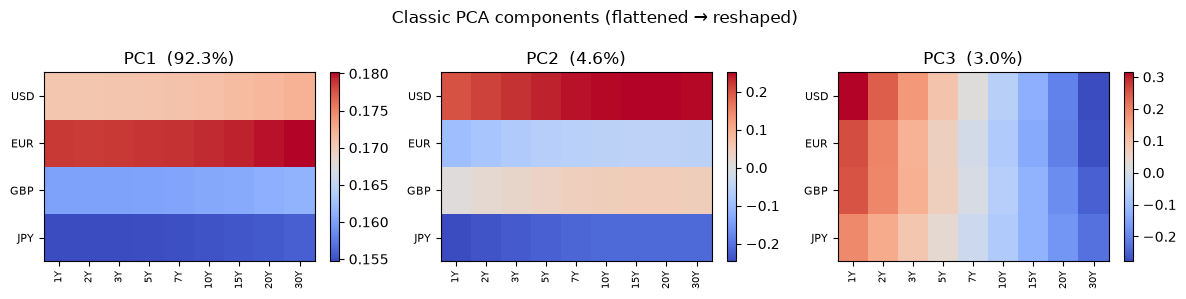

In [11]:
# Reshape top flattened-PCA components back to (currency, tenor) surfaces.
n_show = 3
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3))
for k in range(n_show):
    comp = pca.components_[k].reshape(n_ccy, n_ten)
    ax = axes[k]
    im = ax.imshow(comp, aspect="auto", cmap="coolwarm")
    ax.set_title(f"PC{k+1}  ({evr[k]*100:.1f}%)")
    ax.set_xticks(range(n_ten)); ax.set_xticklabels(tenors, rotation=90, fontsize=7)
    ax.set_yticks(range(n_ccy)); ax.set_yticklabels(currencies, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Classic PCA components (flattened → reshaped)")
fig.tight_layout()
plt.show()

## Tensor PCA methodology (Tucker / HOSVD)

We arrange the centred deviations as a third-order tensor
$\mathcal{X} \in \mathbb{R}^{N \times C \times T}$
(scenarios × currencies × tenors).

**Mode-$n$ unfolding.** Matricizing along mode $n$ flattens all other axes:
$X_{(1)} \in \mathbb{R}^{N \times CT}$,
$X_{(2)} \in \mathbb{R}^{C \times NT}$,
$X_{(3)} \in \mathbb{R}^{T \times NC}$.
Classic PCA is exactly the SVD of $X_{(1)}$ — it only ever sees the mode-1
unfolding, which is why currency and tenor structure get entangled.

**Tucker model.** Tucker factorizes across *all* modes simultaneously:

$$
\mathcal{X} \;\approx\;
\mathcal{G}
\times_1 U^{(1)}
\times_2 U^{(2)}
\times_3 U^{(3)},
$$

where $\mathcal{G} \in \mathbb{R}^{R_1 \times R_2 \times R_3}$ is the **core**,
each $U^{(n)} \in \mathbb{R}^{I_n \times R_n}$ has orthonormal columns, and
$\times_n$ is the mode-$n$ product.

**HOSVD initialization.** Each factor is the leading left singular vectors of the
corresponding unfolding:

$$
X_{(n)} = U^{(n)} \Sigma^{(n)} V^{(n)\top},
\qquad
U^{(n)} \leftarrow \text{first } R_n \text{ columns of } U^{(n)}.
$$

The core is then $\mathcal{G} = \mathcal{X} \times_1 U^{(1)\top}
\times_2 U^{(2)\top} \times_3 U^{(3)\top}$, and an ALS refinement (higher-order
orthogonal iteration) minimizes
$\lVert \mathcal{X} - \hat{\mathcal{X}} \rVert_F$.

**Parameter economy.** Rank-$r$ flattened PCA stores $r\,CT$ loadings (product of
mode sizes); Tucker stores $C R_2 + T R_3 + R_2 R_3$ (sum of mode sizes) — the
source of the 41-vs-144 advantage.

In [15]:
# Tucker decomposition: separate factors per mode.
# ranks = [scenario, currency, tenor].  Keep few tenor & currency factors.
ranks = [4, 2, 3]
core, factors = tucker(tl.tensor(X), rank=ranks, init="svd")
scen_factor, ccy_factor, ten_factor = factors   # (200,4), (4,2), (9,3)

print("core", tuple(core.shape))
print("scenario factor", scen_factor.shape)
print("currency factor", ccy_factor.shape)
print("tenor factor", ten_factor.shape)

# Reconstruction error
Xhat = tl.tucker_to_tensor((core, factors))
rel_err = np.linalg.norm(X - Xhat) / np.linalg.norm(X)
print(f"Tucker relative reconstruction error: {rel_err:.4e}")

core (4, 2, 3)
scenario factor (200, 4)
currency factor (4, 2)
tenor factor (9, 3)
Tucker relative reconstruction error: 1.0057e-14


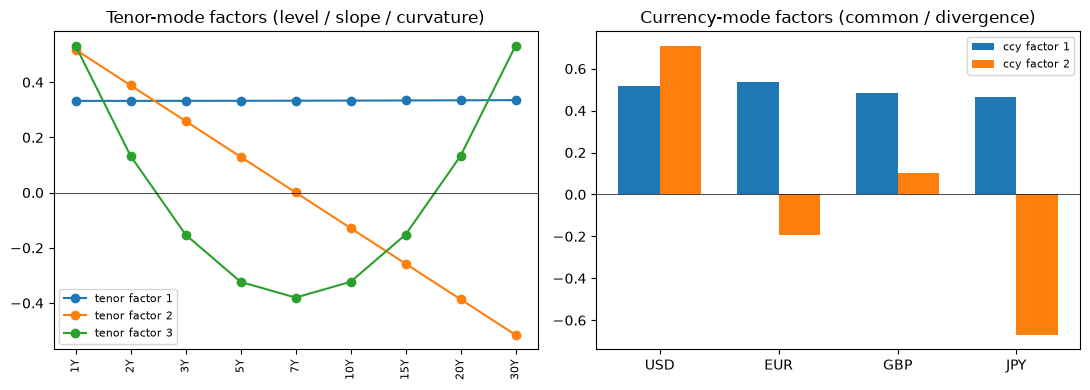

In [16]:
# Tenor-mode factors ≈ level / slope / curvature.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for j in range(ten_factor.shape[1]):
    ax1.plot(range(n_ten), ten_factor[:, j], marker="o", label=f"tenor factor {j+1}")
ax1.set_xticks(range(n_ten)); ax1.set_xticklabels(tenors, rotation=90, fontsize=8)
ax1.set_title("Tenor-mode factors (level / slope / curvature)")
ax1.axhline(0, color="k", lw=0.5); ax1.legend(fontsize=8)

width = 0.35
x = np.arange(n_ccy)
for j in range(ccy_factor.shape[1]):
    ax2.bar(x + j * width, ccy_factor[:, j], width, label=f"ccy factor {j+1}")
ax2.set_xticks(x + width / 2); ax2.set_xticklabels(currencies)
ax2.set_title("Currency-mode factors (common / divergence)")
ax2.axhline(0, color="k", lw=0.5); ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [17]:
# Compare: reconstruction error vs number of free parameters.
# Classic PCA with r components: params = r * 36 (+ r scores per scenario).
# Tucker [R, Rc, Rt]: params = R*200_scores + 4*Rc + 9*Rt + core(R*Rc*Rt).

def pca_rel_err(r):
    p = PCA(n_components=r).fit(Xflat)
    Xr = p.inverse_transform(p.transform(Xflat))
    return np.linalg.norm(Xflat - Xr) / np.linalg.norm(Xflat)

print(f"{'method':>18} {'rel_err':>10} {'loading_params':>15}")
for r in [1, 2, 3, 4, 6]:
    err = pca_rel_err(r)
    params = r * n_ccy * n_ten          # component loadings only
    print(f"{'classic PCA r=' + str(r):>18} {err:>10.4e} {params:>15}")

# Tucker: loading params = currency + tenor factors + core
tuck_params = n_ccy * ranks[1] + n_ten * ranks[2] + np.prod(ranks[1:])
print(f"{'Tucker ' + str(ranks):>18} {rel_err:>10.4e} {tuck_params:>15}")

            method    rel_err  loading_params
   classic PCA r=1 2.7691e-01              36
   classic PCA r=2 1.7450e-01              72
   classic PCA r=3 2.3601e-02             108
   classic PCA r=4 1.5266e-15             144
   classic PCA r=6 1.4562e-15             216
  Tucker [4, 2, 3] 1.0057e-14              41


## Summary — why tensor PCA wins here

The scenario tensor has genuine **multi-mode low-rank structure**: a handful of
shared curve shapes (level/slope/curvature) correlated across currencies, plus a
cross-currency **basis-divergence** factor affecting only the foreign legs.

| Method | rel. error | loading params | interpretable? |
|--------|-----------:|---------------:|:--------------:|
| Classic PCA (r=3) | 2.4e-02 | 108 | ✗ entangled 4×9 surfaces |
| Classic PCA (r=4) | 1.5e-15 | 144 | ✗ entangled 4×9 surfaces |
| **Tucker [4,2,3]** | **1.0e-14** | **41** | ✓ separable ccy × tenor |

**Takeaways**

- Flattening into a length-36 vector forces PCA to *mix* the currency and tenor
  axes into every component, obscuring the underlying drivers.
- Tucker/HOSVD keeps the modes separate, yielding **tenor-mode factors**
  (level / slope / curvature) and **currency-mode factors** (common move vs.
  FX-basis divergence) directly.
- Same reconstruction accuracy at **far lower parameter cost** — the tensor
  factorization matches the true generative model.

**Next steps for a real workbook**
- Replace synthetic shocks with historical curve moves (re-bootstrap per date).
- Add more currencies/tenors — tensor PCA's parameter advantage grows with size.
- Use the scenario scores (`scen_factor`) for risk / stress testing.

In [18]:
# Export figures for the report.
import os
fig_dir = os.path.join("..", "report", "figures")
os.makedirs(fig_dir, exist_ok=True)

# --- Classic PCA component surfaces ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for k in range(3):
    comp = pca.components_[k].reshape(n_ccy, n_ten)
    ax = axes[k]
    im = ax.imshow(comp, aspect="auto", cmap="coolwarm")
    ax.set_title(f"PC{k+1}  ({evr[k]*100:.1f}%)")
    ax.set_xticks(range(n_ten)); ax.set_xticklabels(tenors, rotation=90, fontsize=7)
    ax.set_yticks(range(n_ccy)); ax.set_yticklabels(currencies, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Classic PCA components (flattened -> reshaped)")
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "classic_pca_components.png"), dpi=150, bbox_inches="tight")
plt.close(fig)

# --- Tucker mode factors ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for j in range(ten_factor.shape[1]):
    ax1.plot(range(n_ten), ten_factor[:, j], marker="o", label=f"tenor factor {j+1}")
ax1.set_xticks(range(n_ten)); ax1.set_xticklabels(tenors, rotation=90, fontsize=8)
ax1.set_title("Tenor-mode factors (level / slope / curvature)")
ax1.axhline(0, color="k", lw=0.5); ax1.legend(fontsize=8)

width = 0.35; x = np.arange(n_ccy)
for j in range(ccy_factor.shape[1]):
    ax2.bar(x + j * width, ccy_factor[:, j], width, label=f"ccy factor {j+1}")
ax2.set_xticks(x + width / 2); ax2.set_xticklabels(currencies)
ax2.set_title("Currency-mode factors (common / divergence)")
ax2.axhline(0, color="k", lw=0.5); ax2.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "tucker_mode_factors.png"), dpi=150, bbox_inches="tight")
plt.close(fig)

# --- Scree plot: explained variance ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 9), evr[:8] * 100)
ax.plot(range(1, 9), np.cumsum(evr[:8]) * 100, "o-", color="crimson", label="cumulative")
ax.set_xlabel("Principal component"); ax.set_ylabel("Explained variance (%)")
ax.set_title("Classic PCA scree plot")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "scree_plot.png"), dpi=150, bbox_inches="tight")
plt.close(fig)

print("Figures saved to", os.path.abspath(fig_dir))

Figures saved to /home/jonty/repos/ore/Examples/xccy-tensor-pca/report/figures
